# BPR Financial Distress Early Warning
## 02 — Temporal modeling, ablation, spatial value, and risk prioritization

This notebook models **next-year multi-indicator financial deterioration** for conventional BPRs. It does not estimate probability of default. Model selection uses target years 2019–2023; target year 2024 is retained as the final out-of-time assessment.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from xcap_ews.data import add_ratio_quality_flags, harmonize_2024_monetary_units, load_bpr_panel, validate_panel
from xcap_ews.features import build_feature_panel
from xcap_ews.target import build_deterioration_target
from scripts.run_modeling import run

OUTPUTS = ROOT / "outputs"
print(f"Repository root: {ROOT.resolve()}")

Repository root: /Users/mraffyzeidan/Downloads/xcap


## 1. Rebuild the modeling panel

The 2024 monetary-unit repair is explicit and flagged. Target construction happens before feature evaluation but only uses $t+1$ columns prefixed `target_`; features use information through observation year $t$.

In [2]:
panel = load_bpr_panel(ROOT)
validate_panel(panel)
panel = harmonize_2024_monetary_units(panel)
panel = add_ratio_quality_flags(panel)
panel = build_deterioration_target(panel)
feature_panel = build_feature_panel(panel, spatial_k=8)

target_profile = (feature_panel.dropna(subset=["next_period_deterioration"])
                  .groupby("target_year")
                  .agg(eligible=("Kode_Bank", "size"),
                       events=("next_period_deterioration", "sum"),
                       event_rate=("next_period_deterioration", "mean"))
                  .reset_index())
display(target_profile.style.format({"event_rate": "{:.1%}"}))

,target_year,eligible,events,event_rate
0,2014.000000,887,243,27.4%
1,2015.000000,1211,340,28.1%
2,2016.000000,1204,253,21.0%
3,2017.000000,1188,267,22.5%
4,2018.000000,1162,289,24.9%
5,2019.000000,1222,320,26.2%
6,2020.000000,1483,585,39.4%
7,2021.000000,1458,375,25.7%
8,2022.000000,1428,354,24.8%
9,2023.000000,1391,445,32.0%


## 2. Run reproducible walk-forward experiments

The experiment compares logistic regression and histogram gradient boosting across four layers: financial condition, trends, administrative peers, and coordinate-based spatial neighbors. Regional variables are intentionally absent because no point-in-time external regional data are present.

In [3]:
run(ROOT)
metadata = json.loads((OUTPUTS / "run_metadata.json").read_text())
metadata

{'random_seed': 42,
 'champion_selection_period': 'target years 2019-2023',
 'champion_selection_metric': 'mean PR-AUC',
 'champion_model': 'hist_gbm',
 'champion_feature_set': 'financial_trend',
 'final_holdout_target_year': 2024,
 'final_holdout_pr_auc': 0.49999920695089994,
 'final_holdout_roc_auc': 0.6703428115865,
 'final_holdout_brier': 0.1980415777527262,
 'risk_band_capacity_assumption': {'High Risk': 'top 5%',
  'Watchlist': 'next 15%',
  'Moderate Risk': 'next 30%',
  'Low Risk': 'bottom 50%'},
 'regional_features': 'not available; intentionally omitted',
 'target_semantics': 'next-year multi-indicator deterioration proxy; not default probability'}

## 3. Development-period model and feature-layer comparison

The champion is selected by mean PR-AUC across target years 2019–2023. This happens before inspecting the locked 2024 result in the next section.

,feature_set,model,roc_auc,pr_auc,ks,brier,recall_at_20pct,precision_at_20pct,lift_at_20pct
0,financial_trend,hist_gbm,0.659,0.452,0.252,0.200,32.1%,46.8%,1.60×
1,financial_trend_peer,hist_gbm,0.660,0.449,0.255,0.201,32.2%,46.9%,1.61×
2,financial_trend_peer_spatial,hist_gbm,0.654,0.447,0.236,0.203,32.2%,47.1%,1.61×
3,financial_trend,logistic,0.649,0.441,0.240,0.201,33.0%,47.8%,1.64×
4,financial,hist_gbm,0.644,0.437,0.223,0.202,32.0%,46.5%,1.60×
5,financial_trend_peer_spatial,logistic,0.649,0.436,0.238,0.203,32.5%,47.2%,1.62×
6,financial_trend_peer,logistic,0.649,0.436,0.239,0.203,32.6%,47.3%,1.62×
7,financial,logistic,0.645,0.435,0.225,0.201,32.3%,47.0%,1.61×


array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       ...,

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1.

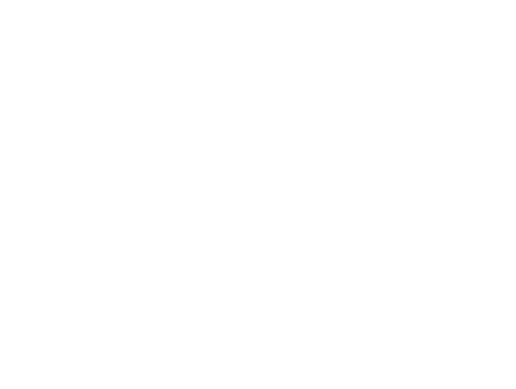

In [4]:
ablation = pd.read_csv(OUTPUTS / "ablation_summary_development.csv")
display(ablation.style.format({
    "roc_auc": "{:.3f}", "pr_auc": "{:.3f}", "ks": "{:.3f}",
    "brier": "{:.3f}", "recall_at_20pct": "{:.1%}",
    "precision_at_20pct": "{:.1%}", "lift_at_20pct": "{:.2f}×",
}))
display(plt.imread(OUTPUTS / "figures" / "ablation_pr_auc.png"))
plt.axis("off"); plt.show()

## 4. Locked 2024 out-of-time result

Performance is reported with discrimination, calibration, and review-capacity metrics. Accuracy is intentionally not the selection objective.

In [5]:
metrics = pd.read_csv(OUTPUTS / "model_metrics_by_year.csv")
final_result = metrics.loc[
    metrics["validation_target_year"].eq(2024)
    & metrics["model"].eq(metadata["champion_model"])
    & metrics["feature_set"].eq(metadata["champion_feature_set"])
]
display(final_result.T)

,43
roc_auc,0.670343
pr_auc,0.499999
ks,0.247284
brier,0.198042
recall_at_20pct,0.320755
precision_at_20pct,0.503704
lift_at_20pct,1.60021
event_rate,0.314774
calibration_intercept,0.111691
calibration_slope,0.965601


## 5. Does spatial information add predictive value?

Moran's I is tested on 2023 NPL net using eight nearest banks and 999 permutations. Statistical significance alone is not enough: the spatial feature layer must also improve out-of-time prediction.

In [6]:
spatial = pd.read_csv(OUTPUTS / "spatial_diagnostics.csv")
display(spatial)

gbm_ablation = ablation.loc[ablation["model"].eq("hist_gbm"), ["feature_set", "roc_auc", "pr_auc", "brier"]]
display(gbm_ablation)

print("Interpretation: dependence is statistically detectable but weak. Peer/spatial layers do not improve development PR-AUC over financial + trend features, so they are monitoring context rather than champion-model inputs.")

,year,indicator,k,morans_i,permutation_p_value_two_sided,permutations
0,2023,NPL_Neto,8,0.058242,0.001,999


,feature_set,roc_auc,pr_auc,brier
0,financial_trend,0.658615,0.452370,0.199924
1,financial_trend_peer,0.660135,0.448880,0.201203
2,financial_trend_peer_spatial,0.654122,0.447007,0.202586
4,financial,0.644424,0.437024,0.202120


Interpretation: dependence is statistically detectable but weak. Peer/spatial layers do not improve development PR-AUC over financial + trend features, so they are monitoring context rather than champion-model inputs.


## 6. Ranking, lift, and risk migration

Risk bands encode review capacity: top 5% High Risk, next 15% Watchlist, next 30% Moderate Risk, and bottom 50% Low Risk. They are ranking bands, not regulatory grades.

,risk_decile,observations,average_probability,deterioration_rate,captured_events,lift
0,1,835,58.8%,54.7%,457,1.82×
1,2,833,42.9%,40.7%,339,1.35×
2,3,832,34.9%,39.3%,327,1.31×
3,4,831,29.1%,33.5%,278,1.11×
4,5,832,24.5%,30.2%,251,1.00×
5,6,834,20.6%,27.7%,231,0.92×
6,7,831,17.4%,20.1%,167,0.67×
7,8,832,14.4%,23.1%,192,0.77×
8,9,833,11.3%,17.8%,148,0.59×
9,10,836,7.7%,13.5%,113,0.45×


,previous_band,Low Risk,Moderate Risk,Watchlist,High Risk
0,Low Risk,0.68,0.23,0.08,0.02
1,Moderate Risk,0.39,0.38,0.18,0.05
2,Watchlist,0.23,0.39,0.27,0.11
3,High Risk,0.18,0.32,0.33,0.17


array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       ...,

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1.

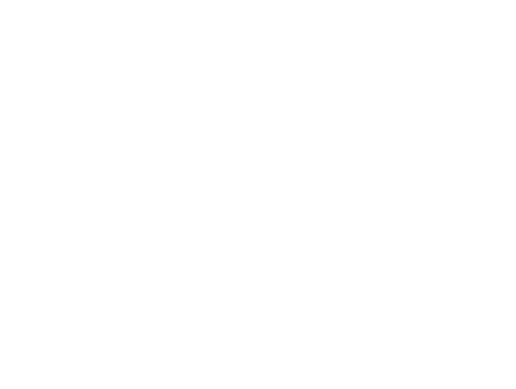

In [7]:
deciles = pd.read_csv(OUTPUTS / "champion_risk_deciles.csv")
migration = pd.read_csv(OUTPUTS / "champion_risk_migration.csv")
display(deciles.style.format({"average_probability": "{:.1%}", "deterioration_rate": "{:.1%}", "lift": "{:.2f}×"}))
display(migration.style.format(precision=2))
display(plt.imread(OUTPUTS / "figures" / "champion_risk_deciles.png"))
plt.axis("off"); plt.show()

## 7. Global and bank-level explanations

Permutation importance is calculated on the locked holdout. Latest bank explanations use model-agnostic median replacement: a positive contribution is the probability increase associated with the observed feature relative to replacing it with the training median. These are predictive explanations, not causal effects.

In [8]:
importance = pd.read_csv(OUTPUTS / "final_holdout_permutation_importance.csv")
display(importance.head(15))

risk_table = pd.read_csv(OUTPUTS / "latest_bank_risk_table.csv")
risk_view = [
    "Kode_Bank", "Nama_BPR", "Provinsi", "Kabupaten_Kota",
    "NPL_Neto", "ROA", "BOPO", "LDR", "KPMM",
    "delta_npl_net_1y", "delta_roa_1y", "delta_bopo_1y",
    "peer_city_npl_net_mean", "spatial_npl_net_mean",
    "predicted_deterioration_probability", "risk_band", "top_risk_drivers",
    "data_quality_flag", "data_quality_reason",
]
display(risk_table[risk_view].head(25).style.format({"predicted_deterioration_probability": "{:.1%}"}))

,feature,pr_auc_importance_mean,pr_auc_importance_std
0,NPL_Neto,0.040411,0.005635
1,loans_to_deposits_calc,0.021812,0.004380
2,delta_roa_1y,0.009446,0.003595
3,provision_to_loans,0.008141,0.002671
4,delta_npl_net_1y,0.007419,0.001833
5,loan_growth_1y,0.007374,0.003841
6,bopo_slope_3y,0.007068,0.009489
7,deposit_share,0.005965,0.003547
8,npl_net_slope_3y,0.005510,0.001773
9,roa_vs_history,0.005421,0.002268


,Kode_Bank,Nama_BPR,Provinsi,Kabupaten_Kota,NPL_Neto,ROA,BOPO,LDR,KPMM,delta_npl_net_1y,delta_roa_1y,delta_bopo_1y,peer_city_npl_net_mean,spatial_npl_net_mean,predicted_deterioration_probability,risk_band,top_risk_drivers,data_quality_flag,data_quality_reason
0,601700,PT Bank Perekonomian Rakyat Arta Mitra Rakyat,Provinsi Jawa Timur,Kab. Malang,5.320000,86.370000,10.830000,24.600000,100.000000,-19.870000,86.680000,-91.960000,16.196190,14.621250,77.1%,High Risk,ROA versus bank history (+0.158); one-year ROA movement (+0.059); profitability level (+0.050),True,ROA outside audit range
1,600935,PT Bank Perekonomian Rakyat Megakerta Swadiri,Provinsi Jawa Timur,Kab. Sidoarjo,39.420000,-0.640000,103.450000,239.740000,116.480000,33.290000,74.510000,-585.070000,12.872632,18.455714,76.5%,High Risk,one-year ROA movement (+0.075); three-year BOPO trend (+0.050); capital adequacy level (+0.031),False,nan
2,602004,PT Bank Perekonomian Rakyat Brata Bhakti Sejahtera,Provinsi Jawa Barat,Kota Depok,25.750000,7.980000,71.340000,95.720000,52.300000,13.760000,52.680000,-247.020000,13.358500,13.760000,74.8%,High Risk,ROA versus bank history (+0.066); three-year BOPO trend (+0.040); one-year ROA movement (+0.037),False,nan
3,601254,PT Bank Perekonomian Rakyat Gede Arthaguna,Provinsi Jawa Barat,Kab. Subang,1.650000,15.900000,80.630000,35.380000,272.540000,-5.640000,39.500000,-219.630000,10.032000,9.830000,74.6%,High Risk,ROA versus bank history (+0.125); one-year ROA movement (+0.109); capital adequacy level (+0.075),True,Cash_Ratio outside audit range
4,601677,PT Bank Perekonomian Rakyat Putra Arta Dewata,Provinsi Jawa Timur,Kota Malang,56.930000,9.280000,70.420000,1975.750000,169.400000,39.310000,30.610000,-141.490000,16.283333,11.796000,73.9%,High Risk,one-year ROA movement (+0.047); three-year BOPO trend (+0.036); profitability level (+0.021),True,LDR outside audit range
5,600193,PT Bank Perekonomian Rakyat Vima,Provinsi Jawa Barat,Kota Bandung,9.720000,19.330000,49.600000,60.880000,29.820000,-14.170000,23.850000,-121.390000,10.457586,6.341250,73.8%,High Risk,three-year BOPO trend (+0.119); ROA versus bank history (+0.101); operating efficiency pressure (+0.075),False,nan
6,601276,PT Bank Perekonomian Rakyat Bangun Mitrawadas,Provinsi Jawa Barat,Kab. Karawang,4.110000,6.060000,79.360000,46.170000,97.050000,1.220000,55.580000,-106.430000,18.055833,21.046000,73.0%,High Risk,one-year ROA movement (+0.117); ROA versus bank history (+0.074); three-year BOPO trend (+0.049),False,nan
7,600097,PT Bank Perekonomian Rakyat Artha Prima Inti,Provinsi Jawa Barat,Kota Cirebon,12.290000,-4.270000,69.430000,81.000000,107.970000,12.290000,158.730000,-749.170000,8.280000,12.920000,72.1%,High Risk,ROA versus bank history (+0.115); one-year ROA movement (+0.081); three-year BOPO trend (+0.074),False,nan
8,601222,PT. BPR Cempaka Mitra Nagari,Provinsi Sumatera Barat,Kota Padang,5.050000,9.020000,60.340000,121.250000,92.450000,0.960000,5.990000,-23.810000,8.230000,8.243333,71.8%,High Risk,ROA versus bank history (+0.157); one-year ROA movement (+0.074); one-year KPMM movement (+0.041),False,nan
9,600864,PT Bank Perekonomian Rakyat Kredit Mandiri Kalsel,Provinsi Kalimantan Selatan,Kab. Banjar,27.460000,3.630000,86.410000,14.570000,334.690000,18.930000,4.990000,-20.140000,4.627500,7.260000,71.7%,High Risk,loan growth (+0.092); capital adequacy level (+0.059); one-year ROA movement (+0.058),True,Cash_Ratio outside audit range


## 8. Visual monitoring gallery

The following views turn model output into an early-warning monitoring workflow: target stability, performance stability, calibration, capture, portfolio allocation, migration, drivers, peer context, and geography.

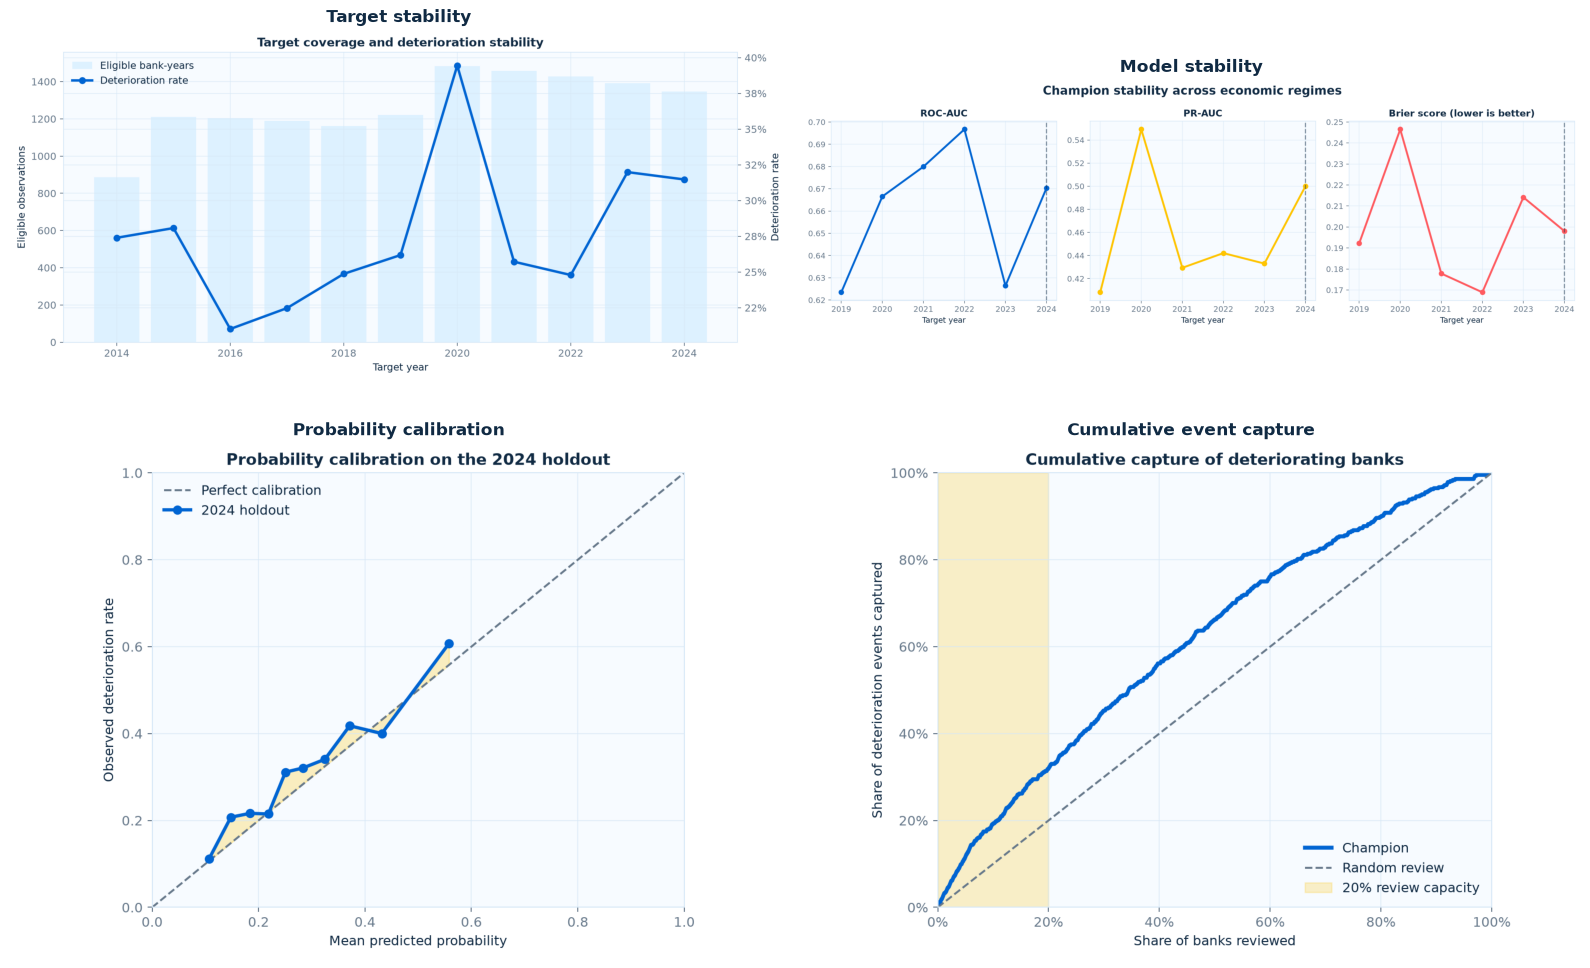

In [9]:
def show_gallery(items, columns=2, width=16):
    rows = (len(items) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(width, rows * 5.2))
    axes = list(getattr(axes, 'flat', [axes]))
    for ax, (filename, title) in zip(axes, items):
        ax.imshow(plt.imread(OUTPUTS / 'figures' / filename))
        ax.set_title(title, fontweight='bold')
        ax.axis('off')
    for ax in axes[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_gallery([
    ('target_stability.png', 'Target stability'),
    ('champion_metric_stability.png', 'Model stability'),
    ('final_holdout_calibration.png', 'Probability calibration'),
    ('final_holdout_cumulative_capture.png', 'Cumulative event capture'),
])

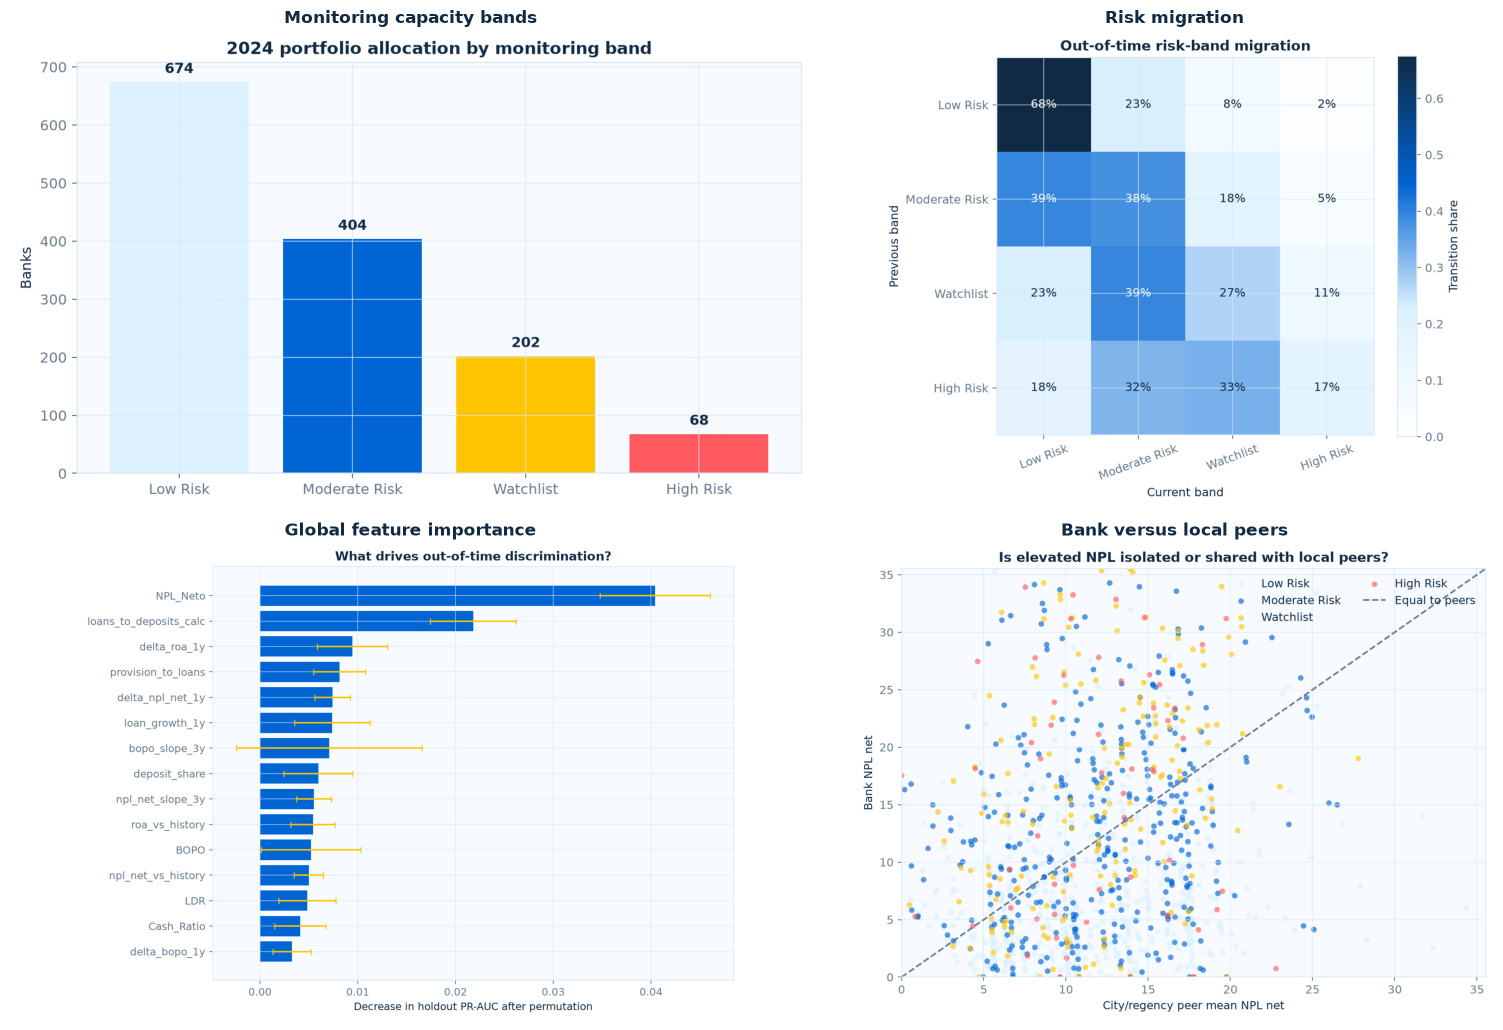

In [10]:
show_gallery([
    ('latest_risk_band_distribution.png', 'Monitoring capacity bands'),
    ('champion_risk_migration.png', 'Risk migration'),
    ('final_holdout_feature_importance.png', 'Global feature importance'),
    ('latest_peer_comparison.png', 'Bank versus local peers'),
])

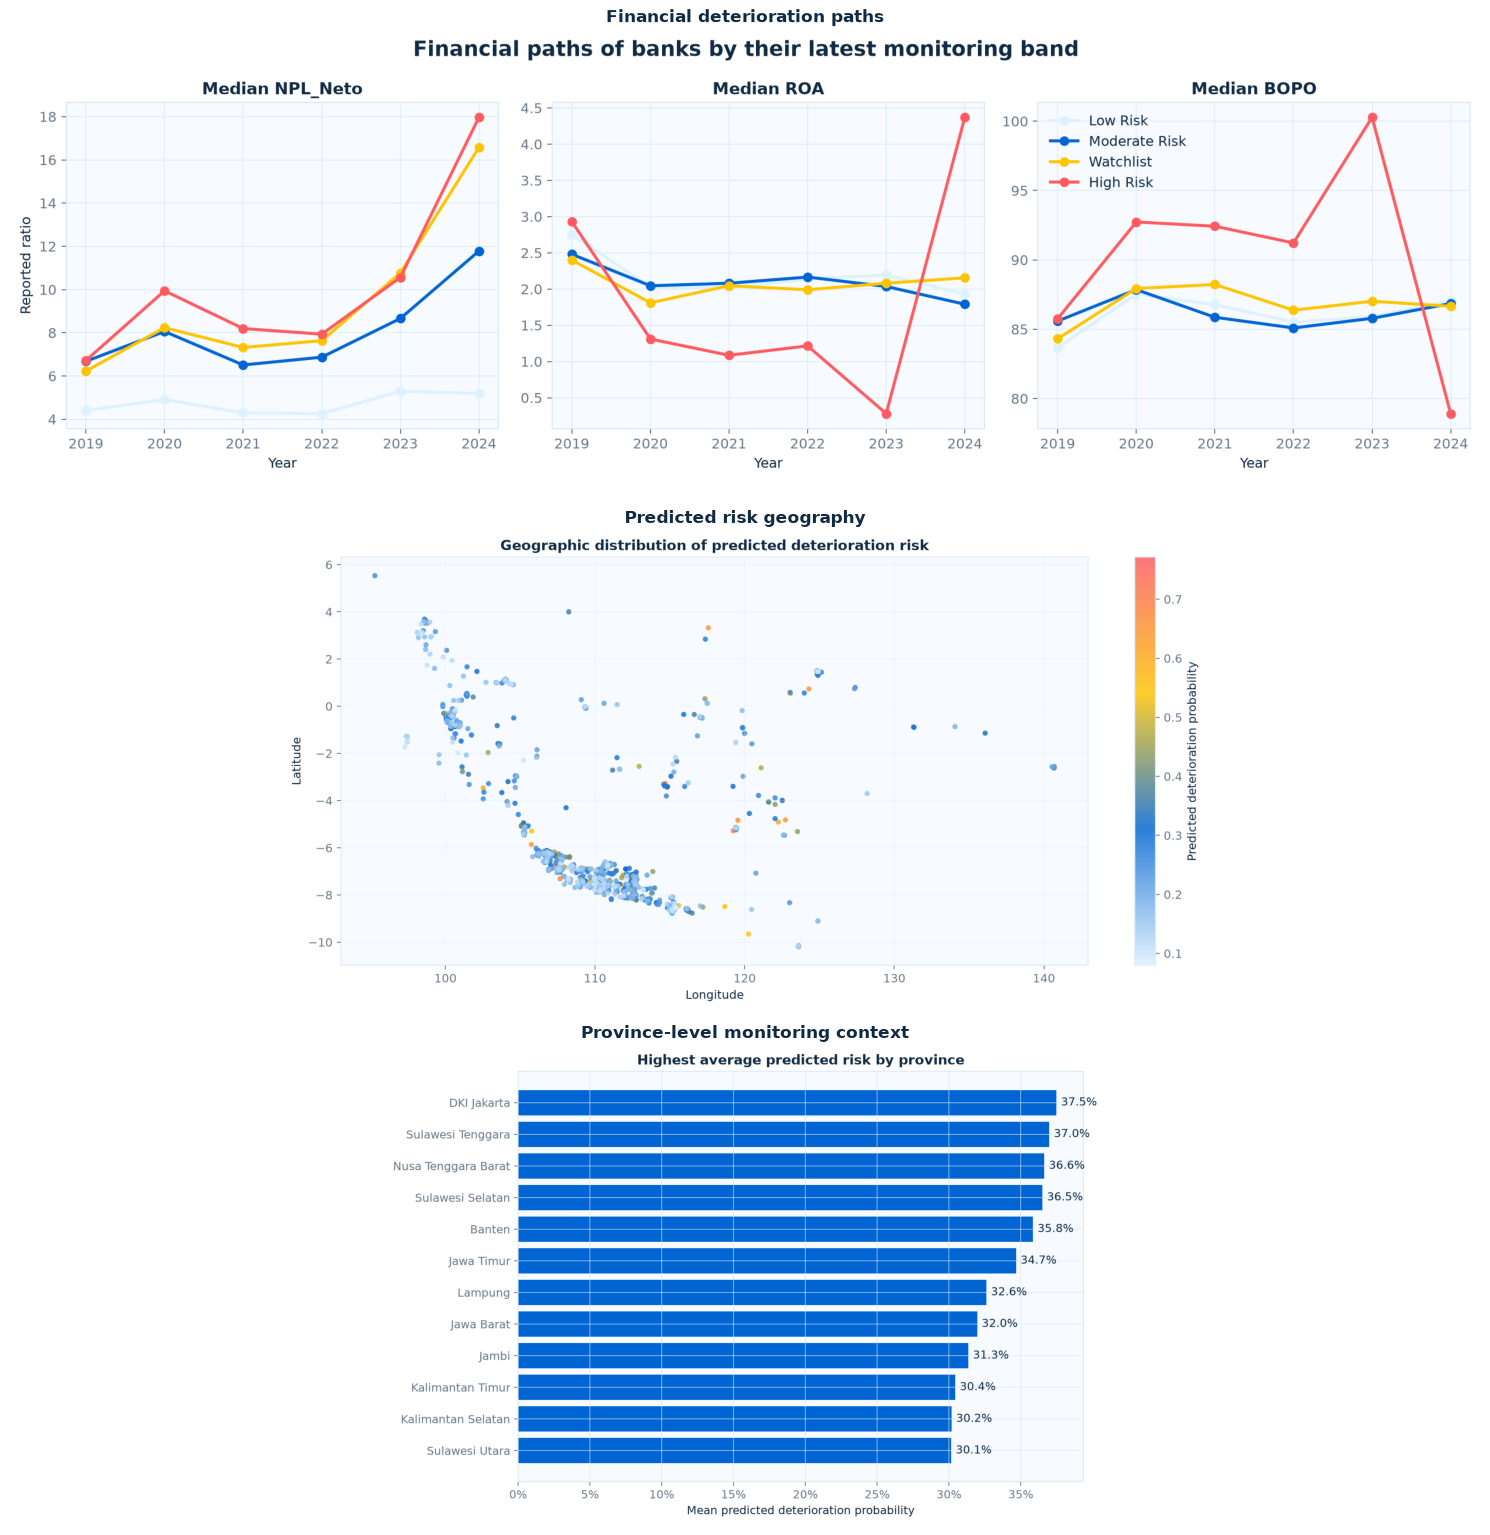

In [11]:
show_gallery([
    ('risk_band_financial_trends.png', 'Financial deterioration paths'),
    ('latest_spatial_risk_map.png', 'Predicted risk geography'),
    ('latest_province_risk.png', 'Province-level monitoring context'),
], columns=1, width=15)

## Conclusion

The current evidence supports a moderate early-warning signal from financial condition and trends. Geographic dependence exists but is weak, and peer/spatial features do not improve development-period PR-AUC enough to enter the champion. They remain useful monitoring context. Before operational use, the remaining priorities are raw-report validation, point-in-time roster reconstruction, probability calibration monitoring, and externally verified distress-event enrichment.